Cell 1 — Setup

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import json
import torch
from pathlib import Path

sys.path.append(str(Path("../src/models").resolve()))
sys.path.append(str(Path("../src/physics").resolve()))
sys.path.append(str(Path("../src/evaluation").resolve()))

from cnn import HeatSurrogateCNN
from benchmark import benchmark_solver, benchmark_cnn

# load best model
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load("../results/best_model.pt", map_location=device)
model      = HeatSurrogateCNN(n_filters=32).to(device)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print(f"Device           : {device}")
print(f"Model loaded     : epoch {checkpoint['epoch']}")
print(f"Parameters       : {model.count_parameters():,}")

Device           : cpu
Model loaded     : epoch 19
Parameters       : 74,433


Cell 2 — Benchmark the solver

In [2]:
print("Benchmarking finite-difference solver...")
print("(200 repeats, stride=10, 64x64 grid)\n")

solver_stats = benchmark_solver(
    N         = 64,
    alpha     = 0.01,
    stride    = 10,
    n_repeats = 200,
    seed      = 0,
)

print(f"\nSolver timing (10 steps, 64x64):")
print(f"  Mean   : {solver_stats['mean']*1000:.4f} ms")
print(f"  Std    : {solver_stats['std']*1000:.4f} ms")
print(f"  Median : {solver_stats['median']*1000:.4f} ms")
print(f"  Min    : {solver_stats['min']*1000:.4f} ms")
print(f"  Max    : {solver_stats['max']*1000:.4f} ms")

Benchmarking finite-difference solver...
(200 repeats, stride=10, 64x64 grid)


Solver timing (10 steps, 64x64):
  Mean   : 0.3133 ms
  Std    : 0.0591 ms
  Median : 0.2921 ms
  Min    : 0.2643 ms
  Max    : 0.6968 ms


Cell 3 — Benchmark the CNN

In [3]:
print(f"\nBenchmarking CNN on device: {device}")
print(f"(200 repeats, 20 warm-up, multiple batch sizes)\n")

batch_sizes = [1, 8, 32, 64, 128]

cnn_stats = benchmark_cnn(
    model        = model,
    device       = device,
    N            = 64,
    batch_sizes  = batch_sizes,
    n_repeats    = 200,
    n_warmup     = 20,
    seed         = 0,
)


Benchmarking CNN on device: cpu
(200 repeats, 20 warm-up, multiple batch sizes)

  Batch size    1:  batch=5.698ms  per-sample=5.6979ms
  Batch size    8:  batch=27.453ms  per-sample=3.4316ms
  Batch size   32:  batch=120.925ms  per-sample=3.7789ms
  Batch size   64:  batch=304.293ms  per-sample=4.7546ms
  Batch size  128:  batch=601.302ms  per-sample=4.6977ms


Cell 4 — Compute and display speedup table

In [4]:
solver_time_ms = solver_stats["mean"] * 1000   # convert to ms

print("=" * 70)
print("TABLE 2 — SPEED COMPARISON: SOLVER vs CNN SURROGATE")
print("=" * 70)
print(f"{'Component':<30} {'Time (ms)':>12} {'Speedup':>10}")
print("-" * 70)
print(f"{'FD Solver (1 sample)':<30} {solver_time_ms:>12.4f} {'1.0x':>10}")

for bs in batch_sizes:
    stats      = cnn_stats[bs]
    t_ms       = stats["per_sample_mean"] * 1000
    speedup    = solver_stats["mean"] / stats["per_sample_mean"]
    label      = f"CNN (batch={bs}, {device})"
    print(f"{label:<30} {t_ms:>12.4f} {speedup:>9.1f}x")

print("=" * 70)
print(f"\nNote: CNN timing includes CPU→{device}→CPU data transfer.")
print(f"Solver: explicit finite differences, {solver_stats['stride']} steps, "
      f"{solver_stats['N']}x{solver_stats['N']} grid.")
print(f"Both produce the same physical output: T(t + {solver_stats['stride']}·Δt)")

TABLE 2 — SPEED COMPARISON: SOLVER vs CNN SURROGATE
Component                         Time (ms)    Speedup
----------------------------------------------------------------------
FD Solver (1 sample)                 0.3133       1.0x
CNN (batch=1, cpu)                   5.6979       0.1x
CNN (batch=8, cpu)                   3.4316       0.1x
CNN (batch=32, cpu)                  3.7789       0.1x
CNN (batch=64, cpu)                  4.7546       0.1x
CNN (batch=128, cpu)                 4.6977       0.1x

Note: CNN timing includes CPU→cpu→CPU data transfer.
Solver: explicit finite differences, 10 steps, 64x64 grid.
Both produce the same physical output: T(t + 10·Δt)


Cell 5 — Speedup visualization

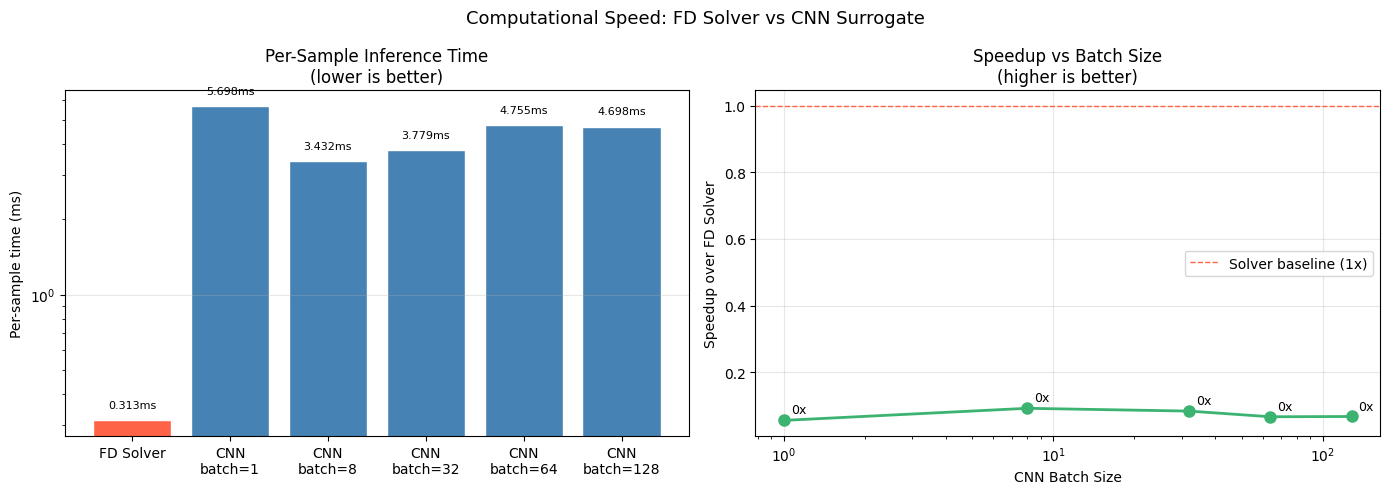

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: per-sample time comparison ────────────────
per_sample_times = [
    cnn_stats[bs]["per_sample_mean"] * 1000
    for bs in batch_sizes
]
speedups = [
    solver_stats["mean"] / cnn_stats[bs]["per_sample_mean"]
    for bs in batch_sizes
]

bar_labels  = [f"CNN\nbatch={bs}" for bs in batch_sizes]
bar_labels  = ["FD Solver"] + bar_labels
bar_times   = [solver_time_ms] + per_sample_times
bar_colors  = ["tomato"] + ["steelblue"] * len(batch_sizes)

bars = axes[0].bar(bar_labels, bar_times, color=bar_colors, edgecolor="white")
axes[0].set_ylabel("Per-sample time (ms)")
axes[0].set_title("Per-Sample Inference Time\n(lower is better)")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3, axis="y")

# annotate bars
for bar, t in zip(bars, bar_times):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() * 1.1,
        f"{t:.3f}ms",
        ha="center", va="bottom", fontsize=8
    )

# ── Right: speedup vs batch size ─────────────────────
axes[1].plot(batch_sizes, speedups, marker="o", color="mediumseagreen",
             linewidth=2, markersize=8)
axes[1].set_xlabel("CNN Batch Size")
axes[1].set_ylabel("Speedup over FD Solver")
axes[1].set_title("Speedup vs Batch Size\n(higher is better)")
axes[1].set_xscale("log")
axes[1].grid(True, alpha=0.3)
axes[1].axhline(1.0, color="tomato", linestyle="--", linewidth=1,
                label="Solver baseline (1x)")
axes[1].legend()

# annotate speedup values
for bs, sp in zip(batch_sizes, speedups):
    axes[1].annotate(f"{sp:.0f}x", (bs, sp),
                     textcoords="offset points", xytext=(5, 5),
                     fontsize=9)

plt.suptitle("Computational Speed: FD Solver vs CNN Surrogate", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/milestone7_speedup.png", dpi=150)
plt.show()

Cell 6 — Scaling experiment: what happens at higher resolution?

Scaling experiment: solver cost vs grid resolution
(CNN fixed at 64x64 — just showing solver scaling)

  N=  32: 0.4056 ms
  N=  64: 0.6620 ms
  N=  96: 1.1789 ms
  N= 128: 1.3925 ms
  N= 512: 127.3809 ms


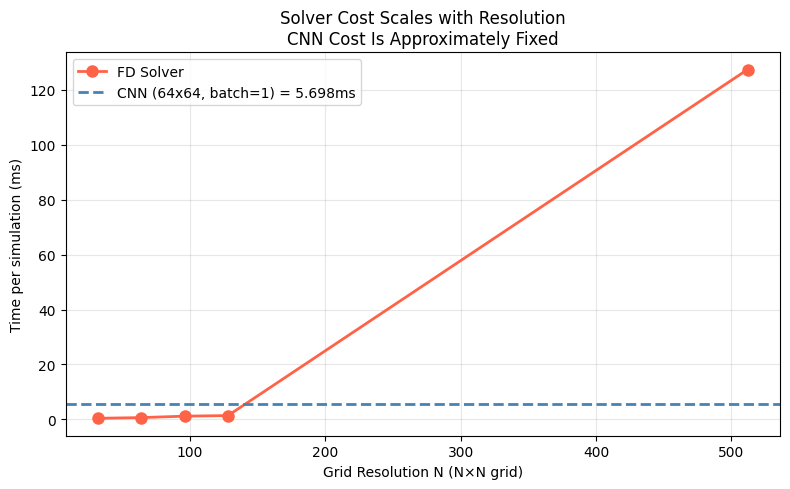


Key insight: solver cost grows roughly as N^2 per fixed stride.
CNN cost is approximately constant (for fixed output size).
Surrogate advantage grows dramatically with resolution.


In [7]:
print("Scaling experiment: solver cost vs grid resolution")
print("(CNN fixed at 64x64 — just showing solver scaling)\n")

resolutions = [32, 64, 96, 128,512]
solver_times_by_res = []

for N_res in resolutions:
    stats = benchmark_solver(
        N         = N_res,
        alpha     = 0.01,
        stride    = 10,
        n_repeats = 100,
    )
    solver_times_by_res.append(stats["mean"] * 1000)
    print(f"  N={N_res:>4}: {stats['mean']*1000:.4f} ms")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(resolutions, solver_times_by_res, marker="o", color="tomato",
        linewidth=2, markersize=8, label="FD Solver")
ax.axhline(cnn_stats[1]["per_sample_mean"] * 1000, color="steelblue",
           linestyle="--", linewidth=2,
           label=f"CNN (64x64, batch=1) = {cnn_stats[1]['per_sample_mean']*1000:.3f}ms")
ax.set_xlabel("Grid Resolution N (N×N grid)")
ax.set_ylabel("Time per simulation (ms)")
ax.set_title("Solver Cost Scales with Resolution\nCNN Cost Is Approximately Fixed")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/milestone7_scaling.png", dpi=150)
plt.show()

print("\nKey insight: solver cost grows roughly as N^2 per fixed stride.")
print("CNN cost is approximately constant (for fixed output size).")
print("Surrogate advantage grows dramatically with resolution.")

Cell 7 — Save all benchmark results

In [8]:
benchmark_results = {
    "solver"    : solver_stats,
    "cnn"       : {str(bs): cnn_stats[bs] for bs in batch_sizes},
    "speedups"  : {str(bs): solver_stats["mean"] / cnn_stats[bs]["per_sample_mean"]
                   for bs in batch_sizes},
    "device"    : str(device),
    "notes"     : {
        "solver_description" : f"Explicit FD, {solver_stats['stride']} steps, "
                               f"{solver_stats['N']}x{solver_stats['N']} grid",
        "cnn_description"    : "Single forward pass, includes data transfer",
        "fair_comparison"    : "Both produce T(t + stride*dt) from T(t)",
    }
}

with open("../results/benchmark_results.json", "w") as f:
    json.dump(benchmark_results, f, indent=2)

print("✓ Benchmark results saved to results/benchmark_results.json")

# print clean summary
print("\n" + "="*50)
print("BENCHMARK SUMMARY")
print("="*50)
print(f"Solver time          : {solver_stats['mean']*1000:.4f} ± "
      f"{solver_stats['std']*1000:.4f} ms")
print(f"CNN time (batch=1)   : "
      f"{cnn_stats[1]['per_sample_mean']*1000:.4f} ms")
print(f"CNN time (batch=128) : "
      f"{cnn_stats[128]['per_sample_mean']*1000:.4f} ms")
print(f"Speedup (batch=1)    : "
      f"{solver_stats['mean']/cnn_stats[1]['per_sample_mean']:.1f}x")
print(f"Speedup (batch=128)  : "
      f"{solver_stats['mean']/cnn_stats[128]['per_sample_mean']:.1f}x")

✓ Benchmark results saved to results/benchmark_results.json

BENCHMARK SUMMARY
Solver time          : 0.3133 ± 0.0591 ms
CNN time (batch=1)   : 5.6979 ms
CNN time (batch=128) : 4.6977 ms
Speedup (batch=1)    : 0.1x
Speedup (batch=128)  : 0.1x
